Filename: m101.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     125   (530, 530)   int16   
  1  Photometric CALTABLE    1 BinTableHDU     39   16R x 4C   [1D, 1D, 1D, 1J]   
there are 2 HDU.
the primary one has the data, of which the index number is 0.
the number type is int16.
SIMPLE            = True
BITPIX            = 16
NAXIS             = 2
NAXIS1            = 530
NAXIS2            = 530
the value for BITPIX = 16, this corresponds with the previous question
(530, 530)
does correspond with the naxis
This data structure is a: >i2
DescribeResult(nobs=280900, minmax=(1507, 15752), mean=4795.924268422927, variance=3416049.866051364, skewness=2.1344311442506223, kurtosis=5.202208842285202)


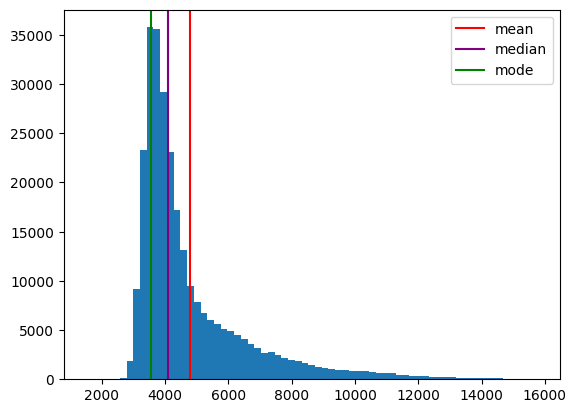

/tmp/ipykernel_3531425/3451860137.py:39: UserWarning: Adding colorbar to a different Figure <Figure size 640x480 with 2 Axes> than <Figure size 640x480 with 1 Axes> which fig.colorbar is called on.
  fig.colorbar(img,cax = cb,label='counts')


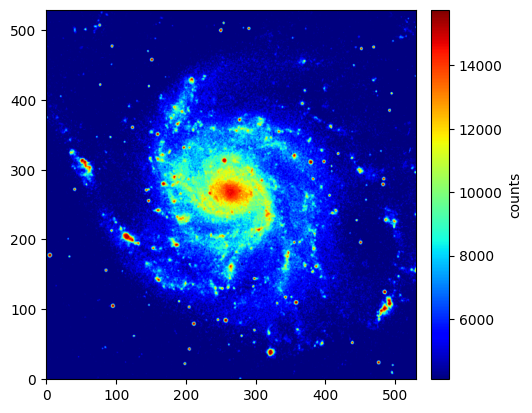

 [astropy.io.fits.verify]


In [47]:
from astropy.io import fits
import numpy as np
import scipy as scp
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

hdulist = fits.open('m101.fits')
hdulist.info()
print(f"there are 2 HDU.\nthe primary one has the data, of which the index number is 0.\nthe number type is int16.")
hdr = hdulist[0].header
for key in hdr[:5]:
    print(f"{key:18s}= {hdr[key]}")
print(f"the value for BITPIX = 16, this corresponds with the previous question")

dat = hdulist[0].data
print(dat.shape)
print("does correspond with the naxis")
print("This data structure is a:", dat.dtype)
datflat = dat.flatten()
print(scp.stats.describe(datflat))

fig, ax = plt.subplots()
ax.hist(datflat,bins=67)
ax.axvline(np.mean(datflat),color='r',label="mean")
ax.axvline(np.median(datflat),color='purple',label="median")
ax.axvline(np.bincount(datflat).argmax(),color='g',label="mode")
ax.legend()
plt.show()

float_dat = np.asarray(dat,dtype=float)
median = np.median(float_dat)
fig1, ax1 = plt.subplots()
img = ax1.imshow(float_dat, origin='lower', cmap = 'jet', vmin=median)


devoder = make_axes_locatable(ax1)
cb = devoder.append_axes("right",size="5%",pad = 0.15)

fig.colorbar(img,cax = cb,label='counts')


ax.set_xlabel(hdr['CTYPE1'])
ax.set_ylabel(hdr['CTYPE2'])

plt.show()


hdr['BUNIT']="Counts"
hdulistout = fits.PrimaryHDU(datflat)
hdulistout.header = hdr
hdulistout.writeto('newfits.fits', overwrite=True, output_verify='ignore')

In [4]:
#6.3
from astropy.io import fits
import numpy as np

hdulist = fits.open('m101.fits')
dat = hdulist[0].data
slicedat = dat[0:21,0:21]

slicedatflat = slicedat.flatten()
sumi = 0
for i in slicedatflat:
    sumi += i**2
    xrms2 = (1/len(slicedatflat)*sumi)**0.5

print(xrms2)        
print(f"mean = {np.mean(slicedat)}, std = {np.std(slicedat)}")        
print("these differ because the mean is calculated differently")
print("I think its the xrms that works best")

3419.889724190472
mean = 3409.875283446712, std = 261.5268188212982
these differ because the mean is calculated differently
I think its the xrms that works best


dat0 std = 9.98401556679484
dat1 std = 10.003955116338458
dat2 std = 9.995349488722516
5.773191380233297
5.77029458336614


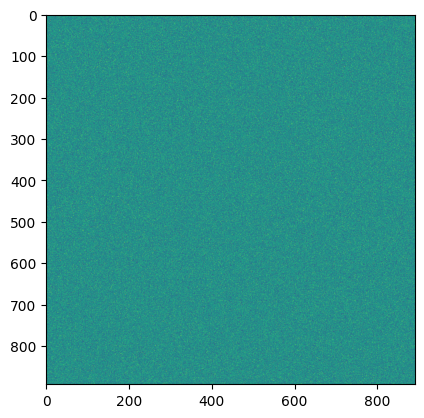

In [18]:
#6.5
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt

noisemap0 = fits.open('noisemap0.fits')
dat0 = noisemap0[0].data
noisemap1 = fits.open('noisemap1.fits')
dat1 = noisemap1[0].data
noisemap2 = fits.open('noisemap2.fits')
dat2 = noisemap2[0].data
print(f"dat0 std = {np.std(dat0)}")
print(f"dat1 std = {np.std(dat1)}")
print(f"dat2 std = {np.std(dat2)}")
datstack = np.stack((dat0,dat1,dat2), axis=0)

mean = np.mean(datstack, axis=0)

std_123 = ((np.std(dat0)**2+np.std(dat1)**2+np.std(dat2)**2)**0.5)/3

std = np.std(mean)

print(std)
print(std_123)

fig = plt.figure()
frame = fig.add_subplot(1,1,1)
frame.imshow(mean)
plt.show()

In [15]:
#6.6

from astropy.io import fits
from astropy.table import Table

# Open the FITS file
hdul = fits.open('APOGEE_stars.fits')

# Access the primary data (in this case, it is a Table)
data = hdul[1].data  # Often, the first extension contains the table
colnames = hdul[1].columns.names # List of the column names

mask = (
    (data['STARFLAG'] == 0) &
    (data['ASPCAPFLAG'] == 0) &
    (data['SNR'] > 10) &
    (data['GAIAEDR3_PARALLAX'] / data['GAIAEDR3_PARALLAX_ERROR'] > 5) &
    np.isfinite(data['GAIAEDR3_PHOT_G_MEAN_MAG']) &
    np.isfinite(data['GAIAEDR3_PHOT_BP_MEAN_MAG']) &
    np.isfinite(data['GAIAEDR3_PHOT_RP_MEAN_MAG'])
)

DATAFLAG = np.where(mask==1,1,0)         #looks where the data according to the mask criteria is one, if not, the value will be set to 0
datatable = Table(data)                  #makes a table of the data
datatable['DATAFLAG'] = DATAFLAG         #adds DATAFLAG to the table

#magnitude conversion
g_mag = data['GAIAEDR3_PHOT_G_MEAN_MAG']
parallax = data['GAIAEDR3_PARALLAX']
distance_pc = np.where(parallax > 0, 1000.0 / parallax, np.nan)        #checks where parallax is larger than 0 (to not get an issue with the log), if it is smaller, convert it to nan. If it is larger than 0, convert it to pcs
absmag = g_mag - 5*np.log10(distance_pc) + 5

absmag[DATAFLAG == 1] = -1.0       #where dataflag = 1 fill a -1 for the data of abs magnitude
datatable['ABSOLUTE_MAG'] = absmag

datatable.write("APOGEE_update.fits", overwrite = True)
hdulist = fits.open("APOGEE_update.fits")
data2 = Table(hdulist[1].data)
data2

GAIAEDR3_PARALLAX,GAIAEDR3_PARALLAX_ERROR,GAIAEDR3_PHOT_G_MEAN_MAG,GAIAEDR3_PHOT_BP_MEAN_MAG,GAIAEDR3_PHOT_RP_MEAN_MAG,ASPCAPFLAG,STARFLAG,SNR,DATAFLAG,ABSOLUTE_MAG
float32,float32,float32,float32,float32,int64,int64,float32,int64,float32
nan,nan,nan,nan,nan,133,0,418.9276,0,nan
0.28544167,0.019475,11.6988,13.2722,10.4956,0,3072,827.1565,0,-1.0236139
0.08209286,0.315081,12.2882,12.5149,11.6597,68,0,229.87506,0,-3.140274
1.2985312,0.00952245,12.2209,12.65,11.6189,0,512,121.3259,0,2.7881622
1.2985312,0.00952245,12.2209,12.65,11.6189,0,0,221.82442,1,-1.0
-0.02394128,0.0450072,16.7478,17.3861,15.9896,0,0,35.325546,0,nan
1.3863556,0.0175672,12.2759,12.8311,11.5693,0,0,294.87552,1,-1.0
2.084405,0.0180373,12.2821,12.5812,11.8179,68,0,126.0876,0,3.8770103
0.12760994,0.0295789,15.551,16.4267,14.6271,0,50331652,116.9411,0,1.0804224


42489404.0
    source_id         ra  ra_error       dec  dec_error  phot_g_mean_flux  \
64   17418337  235.84286  0.005008  11.71101    0.00445        42489404.0   

    phot_g_mean_flux_error  phot_g_mean_mag  phot_bp_mean_flux  \
64                5649.703         6.617699         15722506.0   

    phot_bp_mean_flux_error  phot_bp_mean_mag  phot_rp_mean_flux  \
64                 9947.167          7.360095         31655918.0   

    phot_rp_mean_flux_error  phot_rp_mean_mag  a_g_val  e_bp_min_rp_val  
64                20056.184          6.010764      0.0              0.0  


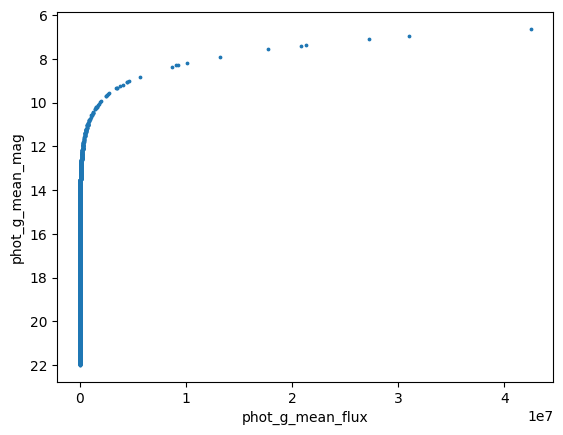

85747110.66914512
19.833048737484173


In [1]:
#6.7
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv('gaiaTestData.csv')
max_phot = data["phot_g_mean_flux"].max()
print(max_phot)
#print(data)
print(data[data["phot_g_mean_flux"] == max_phot])

fig = plt.figure()
ax = fig.add_subplot(1,1,1)
ax.scatter(data["phot_g_mean_flux"],data["phot_g_mean_mag"],s=3)
ax.set_xlabel("phot_g_mean_flux")
ax.set_ylabel("phot_g_mean_mag")
ax.invert_yaxis()
plt.show()

F0 = 10 ** (0.4 * data["phot_g_mean_mag"])
F0mean = np.mean(F0)
m0 = 2.5 * np.log10(F0mean)
print(F0mean)
print(m0)

In [3]:
#6.10
from astroquery.gaia import Gaia
import numpy as np
import pandas as pd

#setting the restrictions on the data
query = """           
SELECT TOP 50
    source_id,
    ra, dec,
    parallax,
    parallax_error,
    phot_g_mean_mag, 
    phot_bp_mean_mag, 
    phot_rp_mean_mag
FROM gaiadr3.gaia_source
WHERE parallax/parallax_error > 5
    AND phot_g_mean_mag IS NOT NULL
    AND phot_bp_mean_mag IS NOT NULL
    AND phot_rp_mean_mag IS NOT NULL
ORDER BY random_index
"""
job = Gaia.launch_job(query)     #executes the query    
results = job.get_results()        #takes the results from the query
panda = results.to_pandas()       #converts it to a panda csv file
panda.head()

,SOURCE_ID,ra,dec,parallax,parallax_error,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag
0,4267180339403392768,286.716913,0.276195,1.084924,0.033431,15.244129,15.942071,14.419943
1,6709252873623174016,276.691194,-46.105121,0.206682,0.040105,15.840754,16.380306,15.151749
2,4040949706019490560,265.229363,-36.358205,0.352725,0.029665,14.802705,16.118845,13.680644
3,4517539583701880064,284.025662,18.403039,0.674962,0.040008,16.073896,16.652264,15.347014
4,1823532754729083392,300.805804,20.601006,0.886435,0.020054,14.375696,14.782262,13.795675


In [6]:
import numpy as np

class Fibonacci:
    """Class for calculating Fibonacci sequence"""
    def __init__(self):
        pass
    
    def fib(self,N):
        a = 0
        b = 1
        for i in range(2, N+1):
            c = a+b
            a = b
            b = c
        return c

    def check(self,N,M):
        
        results=[]
        Nth = self.fib(N)
        a = 0
        b = 1
        c =0
        while c < Nth:
            if c % M == 0:
                results.append(c)

            c = a+b
            a = b
            b = c
        return results

N = eval(input("value for N: "))
M = eval(input("value for M: "))

blah = Fibonacci()
print(blah.fib(N))
print(blah.check(N,M))

value for N: 100
value for M: 7
354224848179261915075
[0, 21, 987, 46368, 2178309, 102334155, 4807526976, 225851433717, 10610209857723, 498454011879264, 23416728348467685, 1100087778366101931, 51680708854858323072]
